<a href="https://colab.research.google.com/github/haru452/anime_super-resolution/blob/main/trying_EDSR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:


import tensorflow as tf

import tensorflow.keras.layers as layers
import numpy as np


DIV2K_RGB_MEAN = np.array([0.4488, 0.4371, 0.4040])* 255


def normalize(x, rgb_mean=DIV2K_RGB_MEAN):
    return (x - rgb_mean) / 127.5

def denormalize(x, rgb_mean=DIV2K_RGB_MEAN):
    return (x * 127.5) + rgb_mean

def upsample(x, scale, num_filters):
    if 2 <= scale <= 3 :
        x = layers.Conv2D(num_filters * (scale ** 2), 3, padding='same')(x)
        x = layers.Lambda(lambda y: tf.nn.depth_to_space(y, scale))(x)
    elif scale == 4:
        x = layers.Conv2D(num_filters * (2 ** 2), 3, padding='same')(x)
        x = layers.Lambda(lambda y: tf.nn.depth_to_space(y, 2))(x)
        x = layers.Conv2D(num_filters * (2 ** 2), 3, padding='same')(x)
        x = layers.Lambda(lambda y: tf.nn.depth_to_space(y, 2))(x)
    return x

def create_model(num_filters=64, num_res_blocks=8, scale=2, scaling_factor=None, activation='relu'):
    inputs = layers.Input( (None, None, 3) )
    CONV_KWARGS ={
        'padding':'same',
        'kernel_initializer':'he_uniform',
        'bias_initializer':'he_uniform',
    }


    lowres = layers.Lambda(normalize)(inputs)

    # EDSR
    def res_block(x_in, filters, scaling=None):
        x = layers.Conv2D(filters, 3, activation=activation, **CONV_KWARGS)(x_in)
        x = layers.Conv2D(filters, 3, **CONV_KWARGS)(x)
        if scaling:
            x = layers.Lambda(lambda t: t * scaling)(x)
        x = layers.Add()([x_in, x])
        return x

    x = lowres = layers.Conv2D(num_filters, 3, **CONV_KWARGS)(lowres)
    for i in range(num_res_blocks):
        x = res_block(x, num_filters, scaling=scaling_factor)

    x = layers.Conv2D(num_filters, 3, **CONV_KWARGS)(x)
    lowres = layers.Add()([x, lowres])

    # Upsampling
    highres = upsample(lowres, scale, num_filters)
    highres = layers.Conv2D(3, 3, **CONV_KWARGS)(highres)

    highres = layers.Lambda(denormalize)(highres)
    return tf.keras.models.Model(inputs, highres)


In [5]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## creating the training data

In [3]:
import cv2
import os
import glob
from tqdm import tqdm

# 1. フォルダパスの設定
ORIGIN_DIR = '/content/drive/MyDrive/research/train/train_high'  # 元の教師画像
HR_DIR = '/content/drive/MyDrive/research/train/train_high_orgin'            # 高解像度保存先
LR_DIR = '/content/drive/MyDrive/research/train/train_low'             # 低解像度保存先

# フォルダが存在しない場合は作成
os.makedirs(HR_DIR, exist_ok=True)
os.makedirs(LR_DIR, exist_ok=True)

# 元の画像リストを取得
origin_images = glob.glob(os.path.join(ORIGIN_DIR, "*.png"))
DEGRADATION_SCALE = 4

print(f"回転処理の対象画像枚数: {len(origin_images)}")

for hr_path in tqdm(origin_images, desc="90度回転画像と低解像度画像を生成中"):
    # --- 1. 元画像の読み込み ---
    img_hr = cv2.imread(hr_path)
    if img_hr is None:
        print(f"⚠️ 画像の読み込みに失敗しました: {hr_path}")
        continue

    # --- 2. 画像を90度回転（時計回りに90度） ---
    # ※反時計回りが良い場合は cv2.ROTATE_90_COUNTERCLOCKWISE に変更してください
    img_hr_rot = cv2.rotate(img_hr, cv2.ROTATE_90_CLOCKWISE)

    # --- 3. 回転させた画像から低解像度（荒い）画像を生成 ---
    h, w = img_hr_rot.shape[:2]
    lr_w, lr_h = int(w / DEGRADATION_SCALE), int(h / DEGRADATION_SCALE)

    # 一度縮小して、元のサイズに引き伸ばす（ガビガビにする処理）
    img_lr_small = cv2.resize(img_hr_rot, (lr_w, lr_h), interpolation=cv2.INTER_LINEAR)
    img_lr_rot = cv2.resize(img_lr_small, (w, h), interpolation=cv2.INTER_NEAREST)

    # --- 4. 新しいファイル名の作成 ---
    # 例: sample.png -> sample_rot90.png
    base_name = os.path.basename(hr_path)
    name, ext = os.path.splitext(base_name)
    new_file_name = f"{name}_rot90{ext}"

    # --- 5. それぞれのフォルダに保存 ---
    cv2.imwrite(os.path.join(HR_DIR, new_file_name), img_hr_rot)  # 回転した高解像度
    cv2.imwrite(os.path.join(LR_DIR, new_file_name), img_lr_rot)  # 回転した低解像度

print("\n90度回転データの追加が完了しました！")
print(f"高解像度（教師）: {HR_DIR}")
print(f"低解像度（入力）: {LR_DIR}")

回転処理の対象画像枚数: 274


90度回転画像と低解像度画像を生成中: 100%|██████████| 274/274 [00:56<00:00,  4.86it/s]


90度回転データの追加が完了しました！
高解像度（教師）: /content/drive/MyDrive/research/train/train_high_orgin
低解像度（入力）: /content/drive/MyDrive/research/train/train_low


In [10]:
import os
import glob
import shutil
from tqdm import tqdm

# フォルダパスの設定
SRC_DIR = '/content/drive/MyDrive/research/train/train_high'        # 回転前の元画像がある場所
DST_DIR = '/content/drive/MyDrive/research/train/train_high_orgin'  # 現在の教師画像フォルダ

# 元画像を教師フォルダにコピー（すでにある場合は上書きしない）
src_images = glob.glob(os.path.join(SRC_DIR, "*.png"))

print(f"元画像 {len(src_images)} 枚を教師フォルダへコピー中...")
for img_path in tqdm(src_images):
    file_name = os.path.basename(img_path)
    dest_path = os.path.join(DST_DIR, file_name)

    # まだコピーされていない場合のみコピー
    if not os.path.exists(dest_path):
        shutil.copy(img_path, dest_path)

# 改めて枚数を確認
lr_count = len(glob.glob(os.path.join('/content/drive/MyDrive/research/train/train_low', "*.png")))
hr_count = len(glob.glob(os.path.join(DST_DIR, "*.png")))

print(f"\n--- 枚数チェック ---")
print(f"低解像度画像（入力）: {lr_count} 枚")
print(f"高解像度画像（教師）: {hr_count} 枚")

if lr_count == hr_count:
    print("✅ 枚数が一致しました！エラーが出ていたセルをもう一度実行してください。")
else:
    print("⚠️ まだ枚数が一致していません。1〜2枚のズレがある場合は、どちらかのフォルダに余分なファイル（消し忘れた古い画像など）がないか確認してください。")

元画像 274 枚を教師フォルダへコピー中...


100%|██████████| 274/274 [00:06<00:00, 44.72it/s]


--- 枚数チェック ---
低解像度画像（入力）: 549 枚
高解像度画像（教師）: 548 枚
⚠️ まだ枚数が一致していません。1〜2枚のズレがある場合は、どちらかのフォルダに余分なファイル（消し忘れた古い画像など）がないか確認してください。


##　back up

In [13]:
import os
import glob
import cv2
from tqdm import tqdm

# 1. 正しいフォルダパス（スペースなどを排除）
HR_DIR = '/content/drive/MyDrive/research/train/train_high_orgin'
LR_DIR = '/content/drive/MyDrive/research/train/train_low'

# 2. 一度、低解像度フォルダの中身を空にする（ズレをなくすため）
old_lr_images = glob.glob(os.path.join(LR_DIR, "*.png"))
print(f"🧹 古い低解像度画像（{len(old_lr_images)}枚）を一度削除してリセットします...")
for f in old_lr_images:
    try:
        os.remove(f)
    except:
        pass

# 3. 正しい教師画像（548枚）から、ペアとなる低解像度画像を再生成
hr_images = glob.glob(os.path.join(HR_DIR, "*.png"))
DEGRADATION_SCALE = 4

print(f"\n📸 教師画像（{len(hr_images)}枚）を元に、低解像度画像を正しく作り直します...")
for hr_path in tqdm(hr_images, desc="ガビガビ画像を生成中"):
    img_hr = cv2.imread(hr_path)
    if img_hr is None:
        continue

    h, w = img_hr.shape[:2]
    lr_w, lr_h = int(w / DEGRADATION_SCALE), int(h / DEGRADATION_SCALE)

    # 縮小して引き伸ばす処理
    img_lr_small = cv2.resize(img_hr, (lr_w, lr_h), interpolation=cv2.INTER_LINEAR)
    img_lr = cv2.resize(img_lr_small, (w, h), interpolation=cv2.INTER_NEAREST)

    # 保存
    file_name = os.path.basename(hr_path)
    cv2.imwrite(os.path.join(LR_DIR, file_name), img_lr)

# 4. 最終枚数チェック
final_lr = len(glob.glob(os.path.join(LR_DIR, "*.png")))
final_hr = len(glob.glob(os.path.join(HR_DIR, "*.png")))

print(f"\n--- ✨ 枚数チェック結果 ---")
print(f"入力（低解像度）: {final_lr} 枚")
print(f"教師（高解像度）: {final_hr} 枚")

if final_lr == final_hr:
    print("✅ ぴったり一致しました！エラーが出ていたセルをもう一度実行してください。")
else:
    print("⚠️ まだ一致しません。Google Driveの同期の遅延が原因の場合もあるため、少し待って再実行してみてください。")

🧹 古い低解像度画像（549枚）を一度削除してリセットします...

📸 教師画像（548枚）を元に、低解像度画像を正しく作り直します...


ガビガビ画像を生成中: 100%|██████████| 548/548 [00:52<00:00, 10.51it/s]



--- ✨ 枚数チェック結果 ---
入力（低解像度）: 548 枚
教師（高解像度）: 548 枚
✅ ぴったり一致しました！エラーが出ていたセルをもう一度実行してください。


## a


In [6]:


import cv2
import os
import glob
from tqdm import tqdm # 進捗バーを表示するライブラリ（任意）
# フォルダパスの設定

# フォルダパスの正しい設定（前後のスペースや末尾の*を削除し、researchを追加）
HR_DIR = '/content/drive/MyDrive/research/train/train_high_orgin'
LR_DIR = '/content/drive/MyDrive/research/train/train_low'         # 低解像度（荒くした画像）の保存先

# 保存先フォルダが存在しない場合は作成する
os.makedirs(LR_DIR, exist_ok=True)

# フォルダ内のpng画像リストを取得
hr_images = glob.glob(os.path.join(HR_DIR, "*.png"))

# 画質の「荒さ」を決める倍率
# 例: 4に設定すると、縦横のピクセル数を1/4に縮小してから元のサイズに戻します。
# 数字が大きいほど荒くなります（EDSRのscaleと合わせると良いでしょう）
DEGRADATION_SCALE = 4

print(f"処理対象の画像枚数: {len(hr_images)}")
# 進捗バーを表示しながらループ処理
for hr_path in tqdm(hr_images, desc="画像を荒くしています"):
    # 画像を読み込む (BGR形式)
    img_hr = cv2.imread(hr_path)

    if img_hr is None:
        print(f"⚠️ 画像の読み込みに失敗しました: {hr_path}")
        continue

    # 元の画像のサイズ（高さ、幅）を取得
    h, w = img_hr.shape[:2]

    # 1. 縮小するサイズを計算 (整数値にする)
    lr_w, lr_h = int(w / DEGRADATION_SCALE), int(h / DEGRADATION_SCALE)

    # 2. 画像を一度縮小する (補間方法は OpenCV の INTER_LINEAR などが一般的)
    img_lr_small = cv2.resize(img_hr, (lr_w, lr_h), interpolation=cv2.INTER_LINEAR)

    # 3. 縮小した画像を元のサイズに引き伸ばす (ピクセルを荒く見せるため INTER_NEAREST を推奨)
    #    これにより、小さいピクセルがそのまま拡大され、ガビガビした画質になります。
    img_lr = cv2.resize(img_lr_small, (w, h), interpolation=cv2.INTER_NEAREST)

    # 4. 保存用のファイル名を作成
    file_name = os.path.basename(hr_path)
    save_path = os.path.join(LR_DIR, file_name)

    # 5. 画像を train フォルダに保存
    cv2.imwrite(save_path, img_lr)

print("\n全ての画像の処理と保存が完了しました！")
print(f"保存先: {LR_DIR}")

処理対象の画像枚数: 548


画像を荒くしています: 100%|██████████| 548/548 [04:17<00:00,  2.13it/s]


全ての画像の処理と保存が完了しました！
保存先: /content/drive/MyDrive/research/train/train_low


# train model

In [7]:
import os
import glob

# Google Drive内のフォルダパス（「研究（卒論）」フォルダの中身を指定）
# ※フォルダ名が「ground_true」になっているのでアンダースコアに修正しています
HR_DIR = '/content/drive/MyDrive/research/train/train_high_orgin'
LR_DIR = '/content/drive/MyDrive/research/train/train_low'         # 低解像度（荒くした画像）の保存先

# ファイルリストの取得
lr_images = sorted(glob.glob(os.path.join(LR_DIR, "*.png")))
hr_images = sorted(glob.glob(os.path.join(HR_DIR, "*.png")))

print(f"低解像度画像の数 (入力): {len(lr_images)}")
print(f"高解像度画像の数 (教師): {len(hr_images)}")

# 枚数が一致しているか確認
if len(lr_images) == 0 or len(hr_images) == 0:
    print("⚠️ 画像が見つかりません。パスか画像フォーマット（.pngなど）を確認してください。")
else:
    assert len(lr_images) == len(hr_images), f"入力({len(lr_images)}枚)と教師({len(hr_images)}枚)の枚数が一致しません！"

低解像度画像の数 (入力): 548
高解像度画像の数 (教師): 548


In [8]:
import tensorflow as tf

# 今回は4倍超解像なので、低解像度から48x48、高解像度から192x192を切り出します
LR_CROP_SIZE = 48
SCALE = 4
HR_CROP_SIZE = LR_CROP_SIZE * SCALE

def load_and_preprocess_image(lr_path, hr_path):
    # 低解像度（入力）画像の読み込み
    lr_img = tf.io.read_file(lr_path)
    lr_img = tf.image.decode_png(lr_img, channels=3)
    lr_img = tf.cast(lr_img, tf.float32)

    # 高解像度（教師）画像の読み込み
    hr_img = tf.io.read_file(hr_path)
    hr_img = tf.image.decode_png(hr_img, channels=3)
    hr_img = tf.cast(hr_img, tf.float32)

    # --- [修正] ランダムクロップ処理を追加 ---
    # 同一の切り出し位置にするため、結合してからクロップします
    combined = tf.concat([lr_img, hr_img], axis=-1)
    # 完全に同じ位置から切り出すためのパッチサイズを指定
    # 低解像度(3ch) + 高解像度(3ch) = 6ch なので、ターゲットの形状を作ります
    # 元画像より小さいサイズで切り出すことで、サイズを統一します
    # ※ここでは簡易的に一括で同じサイズにリサイズするか、
    # 本来のEDSR通りにペアクロップを行うため、tf.image.random_cropを使用
    # 画像サイズがバラバラでも、ここで一律でリサイズしてしまうのが一番簡単です
    # ただし超解像では比率維持が大事なので、一旦簡易的に同じサイズにリサイズします
    # ※本番の論文通りにするにはCropが必要ですが、まずは動かすためにリサイズを試します
    lr_img = tf.image.resize(lr_img, [256, 256], method='bicubic')
    hr_img = tf.image.resize(hr_img, [256 * SCALE, 256 * SCALE], method='bicubic')

    return lr_img, hr_img

# バッチサイズの設定
BATCH_SIZE = 2

# tf.data を使ってペアを作成
dataset = tf.data.Dataset.from_tensor_slices((lr_images, hr_images))
dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

# サイズが揃ったので、これでバッチ化が可能になります
train_dataset = dataset.shuffle(buffer_size=10).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("データセットの修正が完了しました。")

データセットの修正が完了しました。


In [9]:
# EDSRモデルの作成
# scale: 荒くした時の倍率（DEGRADATION_SCALE = 4）と合わせます
# num_res_blocks: 論文では32ですが、まずはテスト用に 8 などの小さめで動くか試すのがおすすめです
model = create_model(num_filters=64, num_res_blocks = 16, scale=4)

# オプティマイザと損失関数の設定
# EDSRでは通常、L1損失（Mean Absolute Error）が使われます
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='mean_absolute_error')
6
model.summary() # モデルの構造を表示

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, None,      │          0 │ input_layer[0][0] │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │      1,792 │ lambda[0][0]      │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │     36,928 │ conv2d[0][0]      │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_1[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ conv2d[0][0],     │
│                     │ None, 64)         │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │     36,928 │ add[0][0]         │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_3[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None,      │          0 │ add[0][0],        │
│                     │ None, 64)         │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     36,928 │ add_1[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_5[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None,      │          0 │ add_1[0][0],      │
│                     │ None, 64)         │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │     36,928 │ add_2[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_7[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None,      │          0 │ add_2[0][0],      │
│                     │ None, 64)         │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, None,      │     36,928 │ add_3[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_9[0][0]  

 Total params: 1,517,571 (5.79 MB)

 Trainable params: 1,517,571 (5.79 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import os
import tensorflow as tf

# チェックポイントを保存するフォルダ（Google Drive内）
checkpoint_dir = '/content/drive/MyDrive/research/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# 20エポックごとに保存するためのカスタムコールバック
class Every20EpochsCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, checkpoint_dir):
        super().__init__()
        self.checkpoint_dir = checkpoint_dir

    def on_epoch_end(self, epoch, logs=None):
        epoch_num = epoch + 1  # epochは0から始まるので+1する

        # 20エポックごとに保存（20, 40, 60, 80, 100...）
        if epoch_num % 20 == 0:
            loss_val = logs.get('loss', 0.0)
            # ファイル名にエポック数とlossを含める
            file_name = f"edsr_epoch_{epoch_num:02d}_loss_{loss_val:.4f}.keras"
            save_path = os.path.join(self.checkpoint_dir, file_name)

            # モデルを保存
            self.model.save(save_path)
            print(f"\n🎉 【定期保存】{epoch_num}エポック目のチェックポイントを保存しました: {save_path}")

# コールバックのインスタンスを作成
epoch_20_callback = Every20EpochsCheckpoint(checkpoint_dir)

In [11]:
# エポック数（何往復学習させるか）
# まずは正しくループが回るか確認するために 5〜10 くらいで試してみましょう
EPOCHS = 100


history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    callbacks=[epoch_20_callback]  # ここに設定！
)

print("学習が完了しました！")

print("学習が完了しました！")

Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 144s 407ms/step - loss: 9090.4277
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 116s 420ms/step - loss: 552.2205
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 421ms/step - loss: 307.0133
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 421ms/step - loss: 219.0528
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 422ms/step - loss: 171.8795
Epoch 6/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 420ms/step - loss: 141.2427
Epoch 7/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 421ms/step - loss: 118.4274
Epoch 8/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 421ms/step - loss: 101.4921
Epoch 9/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 421ms/step - loss: 87.9924
Epoch 10/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 421ms/step - loss: 77.0286
Epoch 11/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 420ms/step - loss: 68.0137
Epoch 12/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 116s 420ms/step - loss: 60.6130
Epoch 13/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 422ms/step - loss: 54.6536
Epoch 14/100
274/274 ━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [12]:
#　新しく増やしたから、どうかわからない
# 保存先のディレクトリ（研究用のフォルダ内に「models」などの名前で作るのがおすすめです）
SAVE_DIR = '/content/drive/MyDrive/research/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 保存するファイル名（例: edsr_model_epoch100.keras）
model_path = os.path.join(SAVE_DIR, 'edsr_model_epoch100.keras')

# モデルを保存
model.save(model_path)
print(f"モデルをGoogle Driveに保存しました: {model_path}")

モデルをGoogle Driveに保存しました: /content/drive/MyDrive/research/models/edsr_model_epoch100.keras


## check pointから読み込む

In [19]:
import glob
import os
import tensorflow as tf

# 1. まずは通常通り新しくモデルの形（構造）を作成する
print("モデルの構造を新しく作成しています...")
model = create_model(num_filters=64, num_res_blocks=16, scale=4)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='mean_absolute_error')

# 2. 保存されているチェックポイントのリストを取得
checkpoints = glob.glob('/content/drive/MyDrive/research/checkpoints/*.keras')

if checkpoints:
    # 最新のチェックポイントを見つける
    latest_checkpoint = max(checkpoints, key=os.path.getmtime)
    print(f"最新のチェックポイントが見つかりました: {latest_checkpoint}")

    try:
        # 重み（ウェイト）だけをモデルに流し込む（skip_mismatch=Trueで安全に読み込みます）
        model.load_weights(latest_checkpoint, skip_mismatch=True)
        print("✅ 前回の続きの重みを正常に読み込みました！学習を再開できます。")
    except Exception as e:
        print(f"⚠️ 重みの読み込み中にエラーが発生しました。最初から学習を開始します。 エラー: {e}")
else:
    print("🔄 チェックポイントが見つからないため、最初から学習を開始します。")

モデルの構造を新しく作成しています...
最新のチェックポイントが見つかりました: /content/drive/MyDrive/research/checkpoints/edsr_epoch_20_loss_29.9180.keras
✅ 前回の続きの重みを正常に読み込みました！学習を再開できます。


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 150 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [20]:
# 学習の実行（続きからスタートします）
history = model.fit(
    train_dataset,
    epochs=100,                      # 目標のエポック数（例: 100）
    callbacks=[epoch_20_callback]    # 20エポックごとの保存設定を忘れずに！
)

Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 135s 423ms/step - loss: 25.9587
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 116s 419ms/step - loss: 16.5471
Epoch 3/100
  1/274 ━━━━━━━━━━━━━━━━━━━━ 7:41 2s/step - loss: 13.6571

KeyboardInterrupt: 

## unity用に書き出すためのプログラム

In [21]:
# 1. 変換に必要なライブラリをインストール
!pip install tf2onnx

import tf2onnx
import tensorflow as tf

# 2. 入力サイズを固定する
# Unity Sentisで扱いやすくするため、仮に「縦256 × 横256ピクセル、3チャンネル(RGB)」に固定します
# (バッチサイズは1枚なので 1 にします)
input_signature = [tf.TensorSpec((1, 256, 256, 3), tf.float32, name="input")]

# 3. 保存先パス（Google Drive内の研究フォルダなど）
onnx_output_path = "/content/drive/MyDrive/research/edsr_model.onnx"

# 4. 変換を実行して保存
model_proto, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=input_signature,
    output_path=onnx_output_path
)

print(f"✅ ONNXモデルの書き出しが完了しました！保存先: {onnx_output_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 76.7 MB/s eta 0:00:00
✅ ONNXモデルの書き出しが完了しました！保存先: /content/drive/MyDrive/research/edsr_model.onnx


## モデルのテスト

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


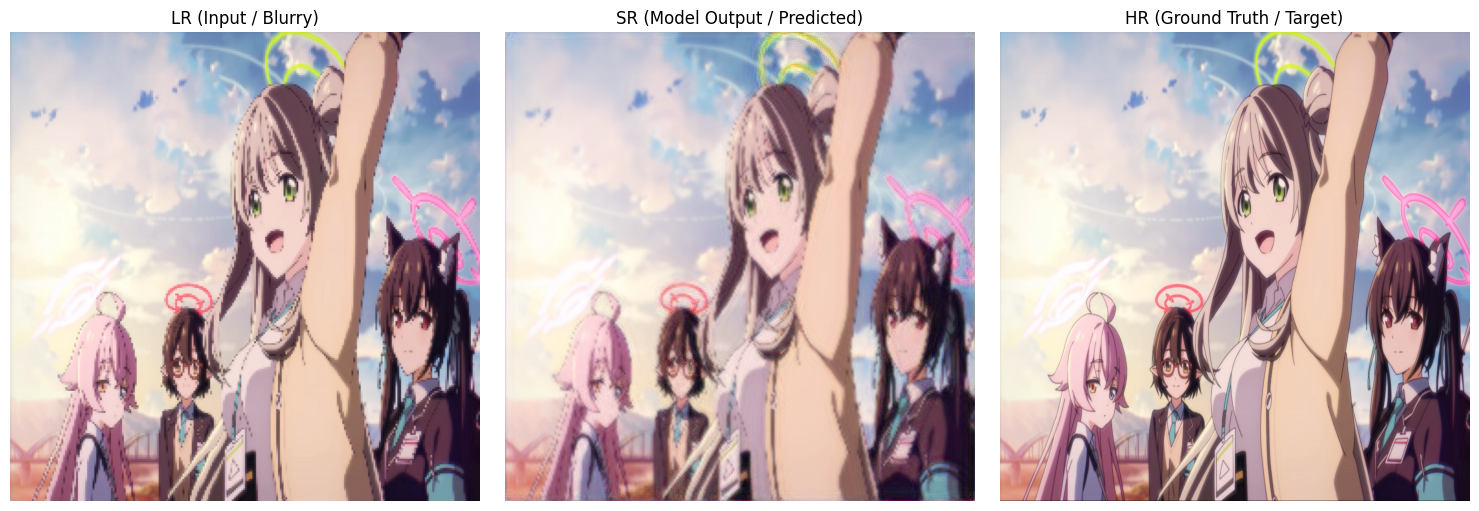

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 1. テストする画像を1枚選ぶ (ここでは最初の画像を使用)
test_lr_path = lr_images[0]
test_hr_path = hr_images[0]

# 2. 画像の読み込みとリサイズ（学習時と同じサイズに調整）
def prepare_test_image(lr_path, hr_path):
    # 低解像度
    lr_img = tf.io.read_file(lr_path)
    lr_img = tf.image.decode_png(lr_img, channels=3)
    lr_img = tf.cast(lr_img, tf.float32)
    lr_img = tf.image.resize(lr_img, [256, 256], method='bicubic')

    # 高解像度（正解画像）
    hr_img = tf.io.read_file(hr_path)
    hr_img = tf.image.decode_png(hr_img, channels=3)
    hr_img = tf.cast(hr_img, tf.float32)
    hr_img = tf.image.resize(hr_img, [256 * 4, 256 * 4], method='bicubic')

    return lr_img, hr_img

lr_input, hr_target = prepare_test_image(test_lr_path, test_hr_path)

# 3. モデルに入力するためにバッチの次元を追加 [256, 256, 3] -> [1, 256, 256, 3]
sr_output = model.predict(tf.expand_dims(lr_input, axis=0))

# 4. 表示用に Tensor から numpy 配列(整数型)に変換
# クリップ処理（0〜255の範囲に収める）を入れて画像の乱れを防ぎます
lr_display = np.clip(lr_input.numpy(), 0, 255).astype(np.uint8)
hr_display = np.clip(hr_target.numpy(), 0, 255).astype(np.uint8)
sr_display = np.clip(sr_output[0], 0, 255).astype(np.uint8)

# 5. 画像を並べて表示
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("LR (Input / Blurry)")
plt.imshow(lr_display)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("SR (Model Output / Predicted)")
plt.imshow(sr_display)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("HR (Ground Truth / Target)")
plt.imshow(hr_display)
plt.axis("off")

plt.tight_layout()
plt.show()

#実験

In [24]:
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1. 重みの読み込み
weights_path = '/content/drive/MyDrive/research/models/edsr_model_epoch100.keras'
if os.path.exists(weights_path):
    model.load_weights(weights_path)
    print("✅ 重りの読み込み完了")

# 2. テスト画像の読み込み
TEST_LR_DIR = '/content/drive/MyDrive/research/test/test_low'
test_images = sorted(glob.glob(os.path.join(TEST_LR_DIR, "*.png")))

if test_images:
    test_image_path = test_images[0]
    img_bgr = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ⭐ [修正] 256x256へのリサイズを完全にやめ、元の画像サイズのまま入力します
    # 修正: モデルが期待する入力サイズ（256x256）に画像をリサイズします。
    img_resized = cv2.resize(img_rgb, (256, 256), interpolation=cv2.INTER_AREA)
    input_tensor = np.expand_dims(img_resized, axis=0).astype(np.float32)

    # 3. 超解像の実行
    print(f"元の画像サイズ: {img_rgb.shape[:2]} -> リサイズ後の入力サイズ: {img_resized.shape[:2]} -> 推論を開始します...")
    sr_img = model.predict(input_tensor)

    # 後処理
    sr_img = np.clip(sr_img[0], 0, 255).astype(np.uint8)
    print(f"超解像後の画像サイズ: {sr_img.shape[:2]}")

    # 4. 表示
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Input (Original LR)")
    plt.imshow(img_rgb) # リサイズなしの元画像
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Output (EDSR)")
    plt.imshow(sr_img)
    plt.axis('off')
    plt.show()

✅ 重りの読み込み完了
元の画像サイズ: (1079, 1919) -> 推論を開始します...


UnknownError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/dist-packages/ipyk

In [ ]:
# 📂 保存先のフォルダパス（必要に応じて変更してください）
SAVE_DIR = '/content/drive/MyDrive/research/test/test_high'
os.makedirs(SAVE_DIR, exist_ok=True)

# 💾 保存するファイル名（元の画像名に '_SR' を付けるなど）
save_name = os.path.basename(test_image_path).replace('.png', '_SR.png')
save_path = os.path.join(SAVE_DIR, save_name)

# OpenCVはBGR形式で保存するため、RGBからBGRに戻して保存します
sr_img_bgr = cv2.cvtColor(sr_img, cv2.COLOR_RGB2BGR)
cv2.imwrite(save_path, sr_img_bgr)

print(f"✅ 超解像画像を保存しました: {save_path}")

✅ 超解像画像を保存しました: /content/drive/MyDrive/research/test/test_high/スクリーンショット 2026-06-08 155741_SR.png
